# 工厂产能与产出：使用 PROC SGPLOT 进行二维组合分析

## 摘要

对于离散制造生产组合中的每条产品线,有两个数字同时重要:**它消耗了多少机器产能**,以及**它实际产出了多少合格品**。一维柱状图只能展示其中一个维度。本笔记本使用 `PROC SGPLOT` 将两者同时可视化,以**气泡图**作为核心视图——每条产品线按产能(x轴)和产出(y轴)定位,气泡大小编码其生产效率(每机时产量)。位于右下方(高产能、低产出)的产品线是产能消耗型;位于左上方且气泡较大的产品线是高产出型。随后的分组柱状图按工厂拆解产出,生产效率排名进一步确认了这一差距。

基于实际执行的输出(三个工厂共八条产品线,100条班次级记录汇总为24个产品线×工厂单元格),分析发现**铸造**是该组合中最明显的产能消耗型产品线(每机时14.3个合格品——消耗总产能的10.1%,却只贡献3.2%的合格品),而**包装**是最突出的高产出型产品线(每小时119.2个单位——9.1%的产能贡献了23.8%的产出)。在各工厂中,**斯图加特**运转效率最高,达每小时49.9个单位,**蒙特雷**最低,为41.6。

## 数据来源

| 数据源 | 描述 | 记录数 |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | 跨8条产品线、3个工厂、3个班次的合成班次级生产记录——计划机时、运行时长、停机时间、总产量/报废/合格品数量(在非授权模式下上限为100个观测) | 100 |
| WORK.LINE_CAPACITY | 按产品线、工厂汇总的摘要:总产能小时数(x)、合格品产量(y)以及验收良率% | 24 |

*所有数据均为合成数据,使用固定随机种子在笔记本内生成——没有外部文件,没有网络。*

# 工厂产能与产出分析

**领域:** 离散制造 —— 运营/工业工程

**过程:** `PROC SGPLOT`(ODS统计图形)

传统的柱状图每个类别只展示一个响应值。要在**两个**数值维度上同时比较一个生产组合——*每条产品线消耗了多少产能*与*它实际产出了多少*——我们需要一张能将两者放在同一画布上的图。`PROC SGPLOT` 的 `BUBBLE` 语句正好做到这一点:它按产能(x)和合格品数量(y)定位每条产品线,并让第三个指标(生产效率)驱动气泡大小。位置偏右但偏低的产品线是产能消耗型;位置偏高偏左且气泡较大的产品线是值得保护的高产出型产品线。本笔记本构建了一个逼真的合成生产数据集,并通过气泡图、按工厂分组的柱状图、单工厂下钻分析,以及并列的工厂聚类比较来驱动 SGPLOT。

> **关于 PROC GAREABAR 的说明。** 经典的 SAS/GRAPH 方式是用 `PROC GAREABAR`(一个仅支持 ActiveX 的面积柱状图,柱宽编码一个变量,柱高编码另一个变量)在每根**柱子**上编码两个维度。GAREABAR **在本 Jenner 构建版本中尚未实现**——该缺口由已归档的测试 `tests/400996_nb_gareabar_unimplemented` 跟踪。本笔记本使用完全支持的 `PROC SGPLOT` 达到相同的分析目标,其气泡图和分组柱状图传达了完全相同的产能与产出对比故事。

## 1. 生成合成生产数据

我们模拟了一个三工厂离散制造网络六周的班次级生产记录。每条产品线都有基准周期时间和报废率;产出由计划机时、工厂特定效率和随机停机时间驱动。`call streaminit` 固定随机种子,使笔记本完全可重现——没有外部文件,没有网络。

In [1]:
/* --------------------------------------------------------
   Synthetic shift-level production runs
   8 product lines x 3 plants x 3 shifts x ~10 days
   width var  = scheduled machine-hours (capacity)
   response   = good units produced  (throughput)
   -------------------------------------------------------- */
数据 work.production_runs;
    调用 streaminit(20260531);
    长度 product_line $24 plant $20 shift $12;

    /* nominal units produced per machine-hour, by line */
    数组 line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* base scrap fraction by line */
    数组 line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    /* plant efficiency multiplier */
    数组 plant_eff[3] _temporary_ (1.00 0.92 1.08);
    数组 shift_eff[3] _temporary_ (1.00 0.95 0.88);

    循环 day = 1 到 10;
        循环 li = 1 到 8;
            循环 pi = 1 到 3;
                循环 si = 1 到 3;
                    如果      li = 1 那么 product_line = "冲压";
                    否则 如果 li = 2 那么 product_line = "焊接";
                    否则 如果 li = 3 那么 product_line = "机加工";
                    否则 如果 li = 4 那么 product_line = "铸造";
                    否则 如果 li = 5 那么 product_line = "注塑";
                    否则 如果 li = 6 那么 product_line = "装配";
                    否则 如果 li = 7 那么 product_line = "精加工";
                    否则                 product_line = "包装";

                    如果      pi = 1 那么 plant = "底特律";
                    否则 如果 pi = 2 那么 plant = "蒙特雷";
                    否则                 plant = "斯图加特";

                    如果      si = 1 那么 shift = "白班";
                    否则 如果 si = 2 那么 shift = "中班";
                    否则                 shift = "夜班";

                    /* scheduled machine-hours for the shift */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* unplanned downtime eats into capacity */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* effective throughput rate with noise */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    输出;
                结束;
            结束;
        结束;
    结束;
    保留 run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    格式 run_date date9.;
运行;

过程 打印 数据=work.production_runs(obs=8) noobs 标签;
    标签 run_date="生产日期" product_line="产品线" plant="工厂" shift="班次"
          sched_hours="计划机时(小时)" run_hours="运行时间(小时)"
          downtime_hours="停机时间(小时)" gross_units="总产量"
          scrap_units="报废数量" good_units="合格品数量";
    标题 "模拟班次级生产记录样本";
运行;
标题;


                                                      模拟班次级生产记录样本                                                       

        生产日期        产品线            工厂      班次              计划机时(小时)              运行时间(小时)              停机时间(小时)        总产量          报废数量            合格品数量
   05JAN2026  冲压         底特律           白班                       7.8                   6.7                   1.1        306            14              292
   05JAN2026  冲压         底特律           中班                       6.8                   6.5                   0.3        259            12              247
   05JAN2026  冲压         底特律           夜班                         8                   7.6                   0.4        269            11              258
   05JAN2026  冲压         蒙特雷           白班                       7.9                   6.8                   1.1        283            12              271
   05JAN2026  冲压         蒙特雷           中班                       7.5                   6.9                   


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.23 seconds
  cpu   0.23 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. 汇总到产品线与工厂级别

图表比较的是每个类别一个数据点,因此我们将班次级明细汇总为按产品线、按工厂的摘要。`total_capacity`(计划机时之和)成为**x**维度,`good_units`(验收产出之和)成为**y**维度,`units_per_hr`(合格品数量 ÷ 产能小时数)是用于决定气泡大小的生产效率指标。我们保留 `plant` 以便稍后用作分组变量。我们还构建了一个跨工厂的产品线级汇总,用于组合气泡图。

In [2]:
/* --------------------------------------------------------
   Roll up to product_line x plant
   total_capacity -> x (capacity hours)
   good_units     -> y (throughput)
   units_per_hr   -> bubble size (productivity)
   -------------------------------------------------------- */
过程 均值 数据=work.production_runs NOPRINT NWAY;
    分类 product_line plant;
    变量 sched_hours good_units scrap_units;
    输出 out=work.line_capacity(删除=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
运行;

数据 work.line_capacity;
    设置 work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    格式 units_per_hr 6.1 yield_pct 5.1;
运行;

过程 排序 数据=work.line_capacity;
    按照 product_line plant;
运行;

/* Line-level roll-up (across all three plants) for the portfolio view */
过程 均值 数据=work.line_capacity NOPRINT NWAY;
    分类 product_line;
    变量 total_capacity good_units;
    输出 out=work.line_total(删除=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
运行;

数据 work.line_total;
    设置 work.line_total;
    units_per_hr = good_units / total_capacity;
    格式 units_per_hr 6.1;
运行;

过程 排序 数据=work.line_total;
    按照 units_per_hr;
运行;

过程 打印 数据=work.line_total noobs 标签;
    变量 product_line total_capacity good_units units_per_hr;
    标签 product_line="产品线" total_capacity="总产能(小时)"
          good_units="合格品数量" units_per_hr="每机时产量";
    标题 "按生产效率排名的产品线组合(每机时合格品数量)";
运行;
标题;


                                                按生产效率排名的产品线组合(每机时合格品数量)                                                 

      产品线            总产能(小时)            合格品数量            每机时产量
铸造                      73.4             1050             14.3
焊接                     130.8             3038             23.2
机加工                    128.9             3762             29.2
冲压                     130.7             4713             36.1
注塑                      66.2             3430             51.8
装配                      67.3             4289             63.7
精加工                     64.6             4927             76.3
包装                      65.9             7855            119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. 打开 ODS 图形目标

`PROC SGPLOT` 通过 ODS 统计图形渲染。我们打开一个 `ODS HTML` 目标,使每张图都以图像形式输出,并打开 `ODS GRAPHICS ON`。不需要特殊的设备驱动程序——与仅支持 ActiveX 的 SAS/GRAPH 过程不同,SGPLOT 与设备无关。

In [3]:
ODS html;
ODS GRAPHICS ON;



NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. 组合气泡图 —— 产能与产出对比

核心视图:`BUBBLE x=total_capacity y=good_units size=units_per_hr`。每条产品线是一个气泡,按总产能小时数(x)和合格品总数(y)定位,气泡面积按其生产效率缩放。`DATALABEL=` 在每个气泡旁打印产品线名称。这正是工厂经理想要的二维对比——产能消耗型产品线落在**右下方**(高机时、低产出、小气泡);高产出型产品线升到**左上方**(低机时、高产出、大气泡)。

                                                     生产组合 - 产能与产出对比                                                     
                                            x = 计划机时；y = 合格品数量；气泡大小 = 每小时产量                                             


右下方 = 产能消耗型产品线；左上方大气泡 = 高产出型产品线。



NOTE: Option TITLE changed to 生产组合 - 产能与产出对比.
NOTE: Option TITLE2 changed to x = 计划机时；y = 合格品数量；气泡大小 = 每小时产量.
NOTE: Option FOOTNOTE changed to 右下方 = 产能消耗型产品线；左上方大气泡 = 高产出型产品线。.
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


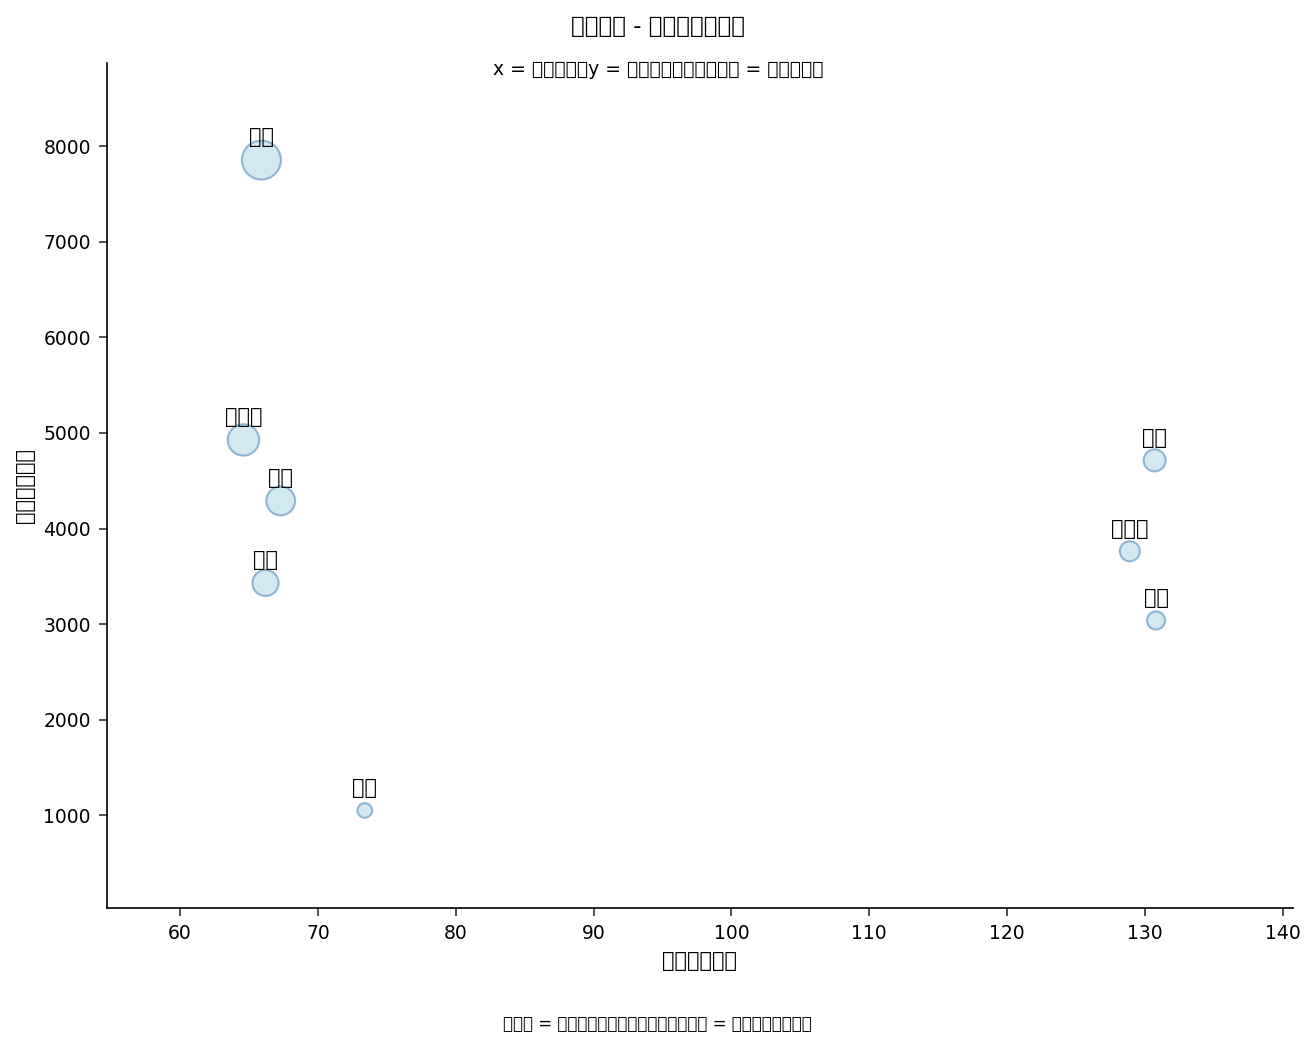

In [4]:
标题 "生产组合 - 产能与产出对比";
title2 "x = 计划机时；y = 合格品数量；气泡大小 = 每小时产量";
footnote JUSTIFY=LEFT
    "右下方 = 产能消耗型产品线；左上方大气泡 = 高产出型产品线。";

过程 SGPLOT 数据=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS 标签="计划机时总计";
    YAXIS 标签="合格品总产量";
运行;

标题; title2; footnote;


## 5. 按产品线的产出,按工厂拆解

为了查看每条产品线的产出如何在三个工厂间分配,`VBAR product_line / response=good_units group=plant` 图表将各工厂的贡献在每根柱子内堆叠。这是分段视图:它同时显示总高度(每条产品线的合格品数量)和柱子内部的工厂构成,便于发现某个工厂主导产出的产品线。

                                                    各产品线合格品数量(按工厂堆叠)                                                    
                                                 柱高 = 合格品总数；分段 = 各工厂贡献                                                  




NOTE: Option TITLE changed to 各产品线合格品数量(按工厂堆叠).
NOTE: Option TITLE2 changed to 柱高 = 合格品总数；分段 = 各工厂贡献.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


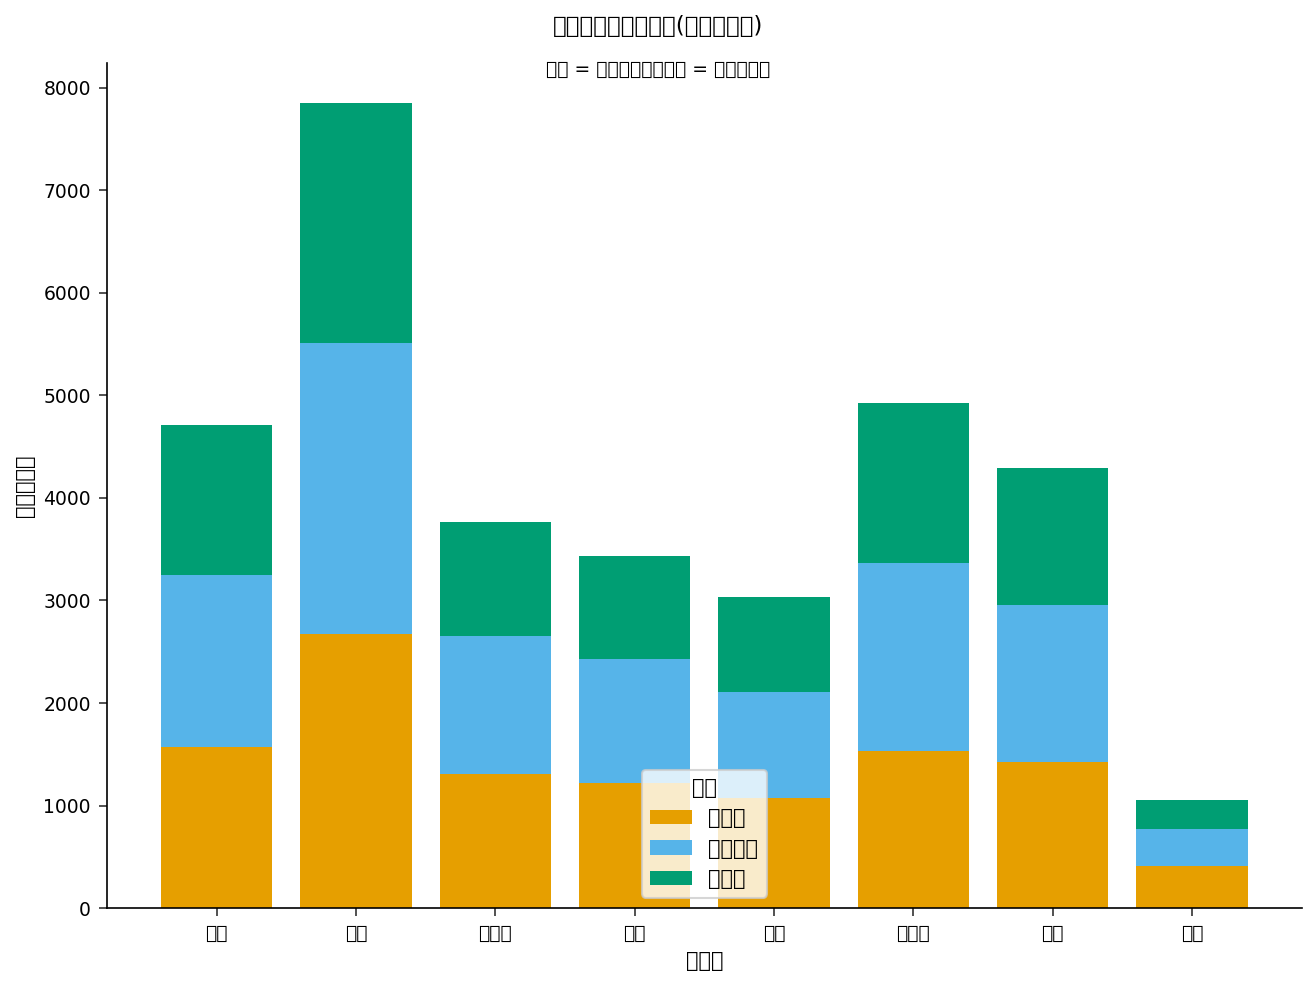

In [5]:
标题 "各产品线合格品数量(按工厂堆叠)";
title2 "柱高 = 合格品总数；分段 = 各工厂贡献";

过程 SGPLOT 数据=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS 标签="产品线" fitpolicy=ROTATE;
    YAXIS 标签="合格品产量";
    keylegend / 标题="工厂" position=bottom;
运行;

标题; title2;


## 6. 单工厂生产效率下钻分析(WHERE)

水平柱状图(`HBAR`)适合较长的产品线标签。`WHERE` 子句筛选出斯图加特工厂的数据,柱状图按 `units_per_hr` 绘制,从而按生产效率对斯图加特的产品线进行排名。由于输入按效率升序排序,效率最低的产品线位于底部,效率最高的位于顶部。

                                                  斯图加特工厂 - 按生产效率排名的产品线                                                  


柱长 = 每机时合格品数量(单厂下钻分析)。



NOTE: Option TITLE changed to 斯图加特工厂 - 按生产效率排名的产品线.
NOTE: Option FOOTNOTE changed to 柱长 = 每机时合格品数量(单厂下钻分析)。.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


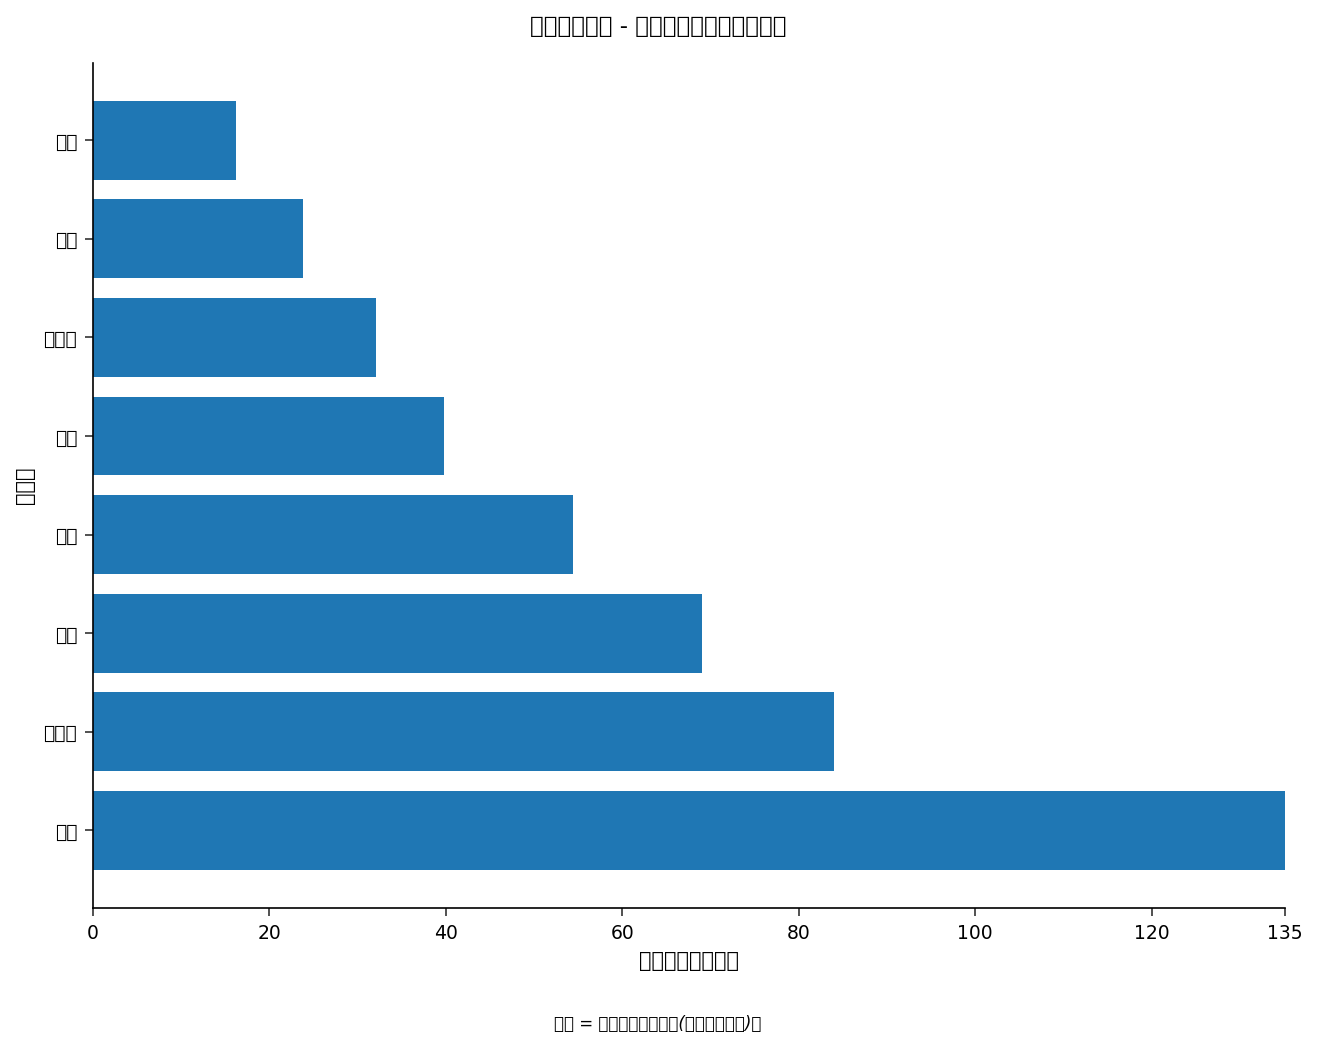

In [6]:
标题 "斯图加特工厂 - 按生产效率排名的产品线";
footnote JUSTIFY=LEFT "柱长 = 每机时合格品数量(单厂下钻分析)。";

过程 SGPLOT 数据=work.line_capacity;
    条件 plant = "斯图加特";
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS 标签="每机时合格品数量";
    YAXIS 标签="产品线";
运行;

标题; footnote;


## 7. 并列工厂对比(聚类柱状图)

为了逐条产品线比较三个工厂,聚类柱状图(`GROUPDISPLAY=CLUSTER`)在每条产品线内将底特律、蒙特雷和斯图加特绘制为相邻的柱子。这是一对一的工厂对比视图:对任意一条产品线,都可以直接读出哪个工厂产出的合格品最多,使工厂间的效率差异(斯图加特最高、蒙特雷最低)一目了然。

                                                 各产品线与工厂合格品数量对比(并列柱状图)                                                  
                                                  簇状柱图：每条产品线内每个工厂一根柱子                                                   




NOTE: Option TITLE changed to 各产品线与工厂合格品数量对比(并列柱状图).
NOTE: Option TITLE2 changed to 簇状柱图：每条产品线内每个工厂一根柱子.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


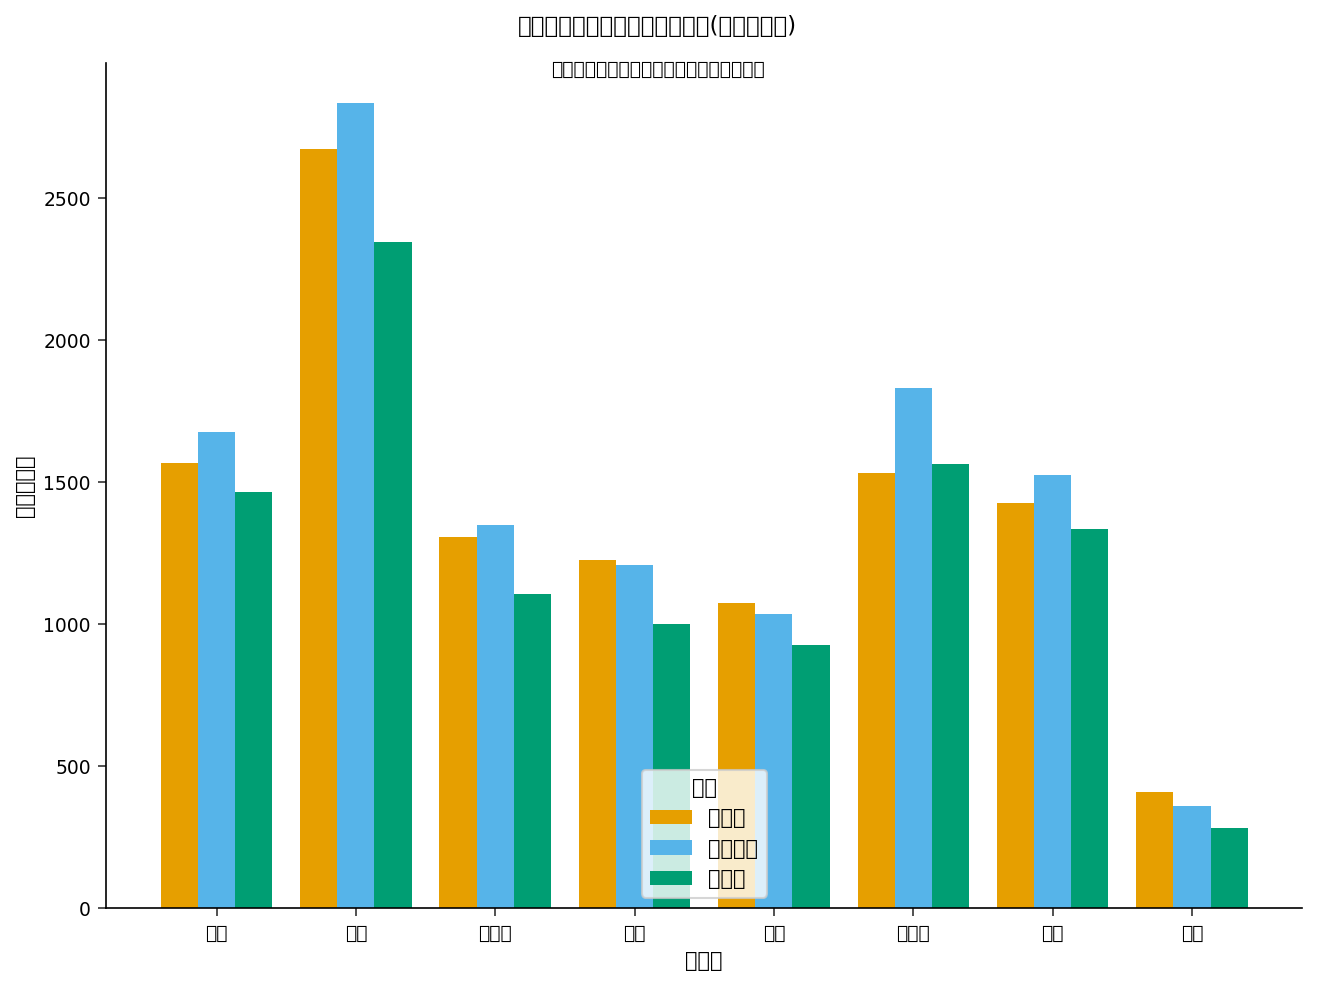

In [7]:
标题 "各产品线与工厂合格品数量对比(并列柱状图)";
title2 "簇状柱图：每条产品线内每个工厂一根柱子";

过程 SGPLOT 数据=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS 标签="产品线" fitpolicy=ROTATE;
    YAXIS 标签="合格品产量";
    keylegend / 标题="工厂" position=bottom;
运行;

标题; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;


## 结果解读

将产能和产出绘制在同一坐标轴上,揭示了一维柱状图会掩盖的关系。**铸造**是该组合中最明显的产能消耗型产品线:在生产效率排名中位居末位,仅为**每机时14.3个合格品**,在气泡图中落在左下方,是一个小气泡——它消耗了总计划机时的**10.1%**,却只贡献了**3.2%**的合格品(由于其报废率较高,它的良率也最低,约为91%)。它是缩短周期时间和降低报废率改善活动的首要候选对象。相反,**包装**是最突出的高产出型产品线,达到**每机时119.2个单位**——一个大气泡位于产出轴的高处,将**9.1%**的产能转化为**23.8%**的全部合格品;保护其正常运行时间将带来不成比例的高产出。**精加工**(76.3单位/小时)和**装配**(63.7)呈现出相同的高产出模式。

这一模式是系统性的:四条缓慢、高产能消耗的上游产品线——铸造、焊接(23.2单位/小时)、机加工(29.2)和冲压(36.1)——合计消耗了约**64%**的计划机时,却只交付了约**38%**的合格品,而四条快速的下游产品线相对于其消耗的机时实现了超额产出。按工厂堆叠的视图和并列聚类柱状图展示了这一现象背后的工厂维度:**斯图加特**运转效率最高,达**每机时49.9个合格品**,**底特律**居中,为**44.9**,**蒙特雷**垫底,为**41.6**——与蒙特雷较高的模拟停机时间相符。从运营角度看,这提示应将计划机时向高产出的下游产品线倾斜,并以斯图加特的做法为基准来改进蒙特雷的停机管理。

*仅为合成数据——数字仅用于说明 `PROC SGPLOT` 的二维产能-产出可视化,并非实际工厂绩效。*